# Blog 1 - Crypto Pre-selection Cointegration Pairs Trading

Notebook bao gồm: ma trận giá, metric pre-selection, cointegration/hedge ratio, spread/z-score, position weights, next-bar PnL và diagnostics

## 1. Research Setup

Dùng formation window để xếp hạng và kiểm định cặp, sau đó dùng phần dữ liệu còn lại làm trading window. Đây là cấu trúc tối thiểu để tránh look-ahead: hedge ratio, p-value, ADF và half-life đều được ước lượng trên formation window; PnL dùng vị thế của bar trước nhân với return của bar sau.

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.signal import coherence
from statsmodels.tsa.stattools import adfuller, coint

PROJECT_ROOT = Path(r"D:\quant idea local\quant-idea\crypto_pairs_trading\stat_arb")
DATA_DIR = PROJECT_ROOT / "csv" / "csv"

SYMBOLS = [
    "PERP:BTC/USDT", "PERP:ETH/USDT", "PERP:SOL/USDT", "PERP:NEAR/USDT",
    "PERP:ADA/USDT", "PERP:AVAX/USDT", "PERP:GALA/USDT", "PERP:1000SHIB/USDT",
    "PERP:XRP/USDT", "PERP:BNB/USDT", "PERP:DOGE/USDT", "PERP:SAND/USDT",
    "PERP:ATOM/USDT", "PERP:DOT/USDT", "PERP:ZIL/USDT",
]

METRICS = [
    "ssd", "price_ratio", "log_price_corr", "return_corr",
    "log_price_cov", "return_cov", "spectral_coherence",
]

FORMATION_BARS = 4320
MAX_PRESELECTED_PAIRS = 25
MAX_COINTEGRATED_PAIRS = 4
ZSCORE_WINDOW = 72
ENTRY_Z = 2.0
EXIT_Z = 0.0
STOP_Z = 4.0
MAX_HOLDING_BARS = 336
FEE_BPS = 4.0
PERIODS_PER_YEAR = 8760


## 2. Price Matrix

Dữ liệu đầu vào duy nhất là ma trận giá close theo thời gian. Mọi thứ sau đó là biến đổi toán học trên ma trận này.

In [2]:
def crypto_symbol_file(symbol: str) -> Path:
    name = symbol.replace("PERP:", "PERP_").replace("/", "_") + "_1h.csv"
    return DATA_DIR / name


def load_price_matrix(symbols: list[str]) -> pd.DataFrame:
    frames = []
    for symbol in symbols:
        frame = pd.read_csv(crypto_symbol_file(symbol), usecols=["bar_time", "symbol", "close"])
        frame["bar_time"] = pd.to_datetime(frame["bar_time"]).dt.tz_localize(None)
        frames.append(frame)
    raw = pd.concat(frames, ignore_index=True)
    prices = raw.pivot(index="bar_time", columns="symbol", values="close").sort_index()
    return prices.astype(float)


prices = load_price_matrix(SYMBOLS)
formation_prices = prices.iloc[:FORMATION_BARS]
trading_prices = prices.iloc[FORMATION_BARS:]
prices.tail()


symbol,PERP:1000SHIB/USDT,PERP:ADA/USDT,PERP:ATOM/USDT,PERP:AVAX/USDT,PERP:BNB/USDT,PERP:BTC/USDT,PERP:DOGE/USDT,PERP:DOT/USDT,PERP:ETH/USDT,PERP:GALA/USDT,PERP:NEAR/USDT,PERP:SAND/USDT,PERP:SOL/USDT,PERP:XRP/USDT,PERP:ZIL/USDT
bar_time,,,,,,,,,,,,,,,
2026-05-30 20:00:00,0.005532,0.2374,2.028,8.995,719.88,73944.5,0.10125,1.197,2026.30,0.003134,2.312,0.07005,82.91,1.3473,0.00380
2026-05-30 21:00:00,0.005532,0.2374,2.027,8.994,719.60,73954.8,0.10126,1.198,2027.54,0.003127,2.295,0.07003,82.96,1.3495,0.00381
2026-05-30 22:00:00,0.005497,0.2359,2.011,8.937,716.27,73849.8,0.10064,1.187,2022.51,0.003099,2.267,0.06939,82.61,1.3419,0.00379
2026-05-30 23:00:00,0.005494,0.2358,2.017,8.942,719.01,73856.8,0.10056,1.189,2021.58,0.003105,2.248,0.06940,82.69,1.3402,0.00379
2026-05-31 00:00:00,0.005501,0.2365,2.014,8.969,723.64,74003.7,0.10085,1.192,2026.00,0.003113,2.245,0.06987,82.90,1.3396,0.00380


## 3. Pre-selection Metrics

Pre-selection là prior của strategy. SSD và price ratio ưu tiên hai đường giá normalized đi gần nhau; correlation/covariance ưu tiên đồng biến; spectral coherence ưu tiên common movement ở miền tần số.

In [3]:
def volatility_adjusted_log_prices(prices: pd.DataFrame, span: int = 72) -> pd.DataFrame:
    log_prices = np.log(prices)
    returns = log_prices.diff()
    vol = returns.ewm(span=span, adjust=False).std()
    return returns.div(vol.replace(0, np.nan)).cumsum()


def normalized_price_index(log_prices: pd.DataFrame) -> pd.DataFrame:
    first_valid = log_prices.apply(lambda series: series.dropna().iloc[0])
    return np.exp(log_prices - first_valid)


def zero_frequency_coherence(ret_a: pd.Series, ret_b: pd.Series) -> float:
    aligned = pd.concat([ret_a, ret_b], axis=1).dropna()
    _, values = coherence(aligned.iloc[:, 0], aligned.iloc[:, 1], nperseg=256)
    return float(values[0])


def preselection_value(metric: str, log_a, log_b, idx_a, idx_b, ret_a, ret_b) -> float:
    if metric == "ssd":
        return float(((idx_a - idx_b) ** 2).sum())
    if metric == "price_ratio":
        return float(abs(idx_a.div(idx_b.replace(0, np.nan)).mean() - 1.0))
    if metric == "log_price_corr":
        return float(abs(log_a.corr(log_b)))
    if metric == "return_corr":
        return float(abs(ret_a.corr(ret_b)))
    if metric == "log_price_cov":
        return float(abs(log_a.cov(log_b)))
    if metric == "return_cov":
        return float(abs(ret_a.cov(ret_b)))
    return zero_frequency_coherence(ret_a, ret_b)


def rank_pairs(prices: pd.DataFrame, metric: str, max_pairs: int) -> pd.DataFrame:
    log_prices = volatility_adjusted_log_prices(prices)
    indexed = normalized_price_index(log_prices)
    returns = log_prices.diff()
    records = []
    for symbol_a, symbol_b in combinations(log_prices.columns, 2):
        frame = pd.concat(
            [
                log_prices[symbol_a], log_prices[symbol_b], indexed[symbol_a],
                indexed[symbol_b], returns[symbol_a], returns[symbol_b],
            ],
            axis=1,
        ).dropna()
        value = preselection_value(
            metric, frame.iloc[:, 0], frame.iloc[:, 1], frame.iloc[:, 2],
            frame.iloc[:, 3], frame.iloc[:, 4], frame.iloc[:, 5],
        )
        score = -value if metric in {"ssd", "price_ratio"} else value
        records.append({"symbol_a": symbol_a, "symbol_b": symbol_b, "metric_value": value, "score": score})
    ranked = pd.DataFrame(records).sort_values("score", ascending=False).head(max_pairs).reset_index(drop=True)
    ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))
    return ranked


rank_pairs(formation_prices, "ssd", 5)


,rank,symbol_a,symbol_b,metric_value,score
0,1,PERP:1000SHIB/USDT,PERP:GALA/USDT,25.348423,-25.348423
1,2,PERP:1000SHIB/USDT,PERP:SAND/USDT,60.666935,-60.666935
2,3,PERP:GALA/USDT,PERP:SAND/USDT,106.705730,-106.705730
3,4,PERP:AVAX/USDT,PERP:GALA/USDT,9022.812543,-9022.812543
4,5,PERP:1000SHIB/USDT,PERP:AVAX/USDT,9082.370457,-9082.370457


## 4. Cointegration, Hedge Ratio, Half-life

Sau pre-selection, ta kiểm tra xem spread có stationary không. Hedge ratio được ước lượng bằng OLS trên formation window, rồi residual được dùng cho ADF và half-life.

In [4]:
def hedge_ratio(y: pd.Series, x: pd.Series) -> float:
    frame = pd.concat([y, x], axis=1).dropna()
    model = sm.OLS(frame.iloc[:, 0], sm.add_constant(frame.iloc[:, 1])).fit()
    return float(model.params.iloc[1])


def spread_from_beta(price_a: pd.Series, price_b: pd.Series, beta: float) -> pd.Series:
    return price_a - beta * price_b


def half_life(spread: pd.Series) -> float:
    aligned = pd.concat([spread.diff(), spread.shift(1)], axis=1).dropna()
    model = sm.OLS(aligned.iloc[:, 0], sm.add_constant(aligned.iloc[:, 1])).fit()
    phi = model.params.iloc[1]
    return float(-np.log(2) / phi) if phi < 0 else np.inf


def cointegration_candidates(prices: pd.DataFrame, ranked_pairs: pd.DataFrame) -> pd.DataFrame:
    log_prices = np.log(prices)
    records = []
    for row in ranked_pairs.itertuples(index=False):
        symbol_a, symbol_b = row.symbol_a, row.symbol_b
        pair = log_prices[[symbol_a, symbol_b]].dropna()
        test_stat, pvalue, _ = coint(pair[symbol_a], pair[symbol_b])
        beta = hedge_ratio(pair[symbol_a], pair[symbol_b])
        spread = spread_from_beta(pair[symbol_a], pair[symbol_b], beta)
        adf_pvalue = adfuller(spread.dropna(), autolag="AIC")[1]
        hl = half_life(spread)
        if pvalue <= 0.10 and adf_pvalue <= 0.05 and 12 <= hl <= 240:
            records.append(
                {
                    "rank": row.rank, "symbol_a": symbol_a, "symbol_b": symbol_b,
                    "pvalue": pvalue, "adf_pvalue": adf_pvalue,
                    "half_life": hl, "hedge_ratio": beta,
                }
            )
    return pd.DataFrame(records).head(MAX_COINTEGRATED_PAIRS)


ssd_candidates = cointegration_candidates(formation_prices, rank_pairs(formation_prices, "ssd", MAX_PRESELECTED_PAIRS))
ssd_candidates


,rank,symbol_a,symbol_b,pvalue,adf_pvalue,half_life,hedge_ratio
0,1,PERP:1000SHIB/USDT,PERP:GALA/USDT,0.063318,0.017689,116.109959,0.671528
1,5,PERP:1000SHIB/USDT,PERP:AVAX/USDT,0.099439,0.030874,92.627343,0.699072
2,22,PERP:BNB/USDT,PERP:ETH/USDT,0.071505,0.020427,111.985931,0.663739
3,24,PERP:BNB/USDT,PERP:BTC/USDT,0.068943,0.019639,148.045821,0.927807


## 5. Z-score Signal và Next-bar PnL

Tín hiệu dùng z-score của spread. PnL dùng weights đã shift một bar để phản ánh quyết định ở bar trước được ăn return ở bar sau.

In [5]:
def zscore(series: pd.Series, window: int) -> pd.Series:
    return (series - series.rolling(window).mean()) / series.rolling(window).std()


def spread_position(z: pd.Series, entry_z: float, exit_z: float, stop_z: float, max_holding: int) -> pd.Series:
    current = 0.0
    bars_held = 0
    positions = []
    for value in z:
        if current == 0.0:
            bars_held = 0
            if value <= -entry_z:
                current = 1.0
            if value >= entry_z:
                current = -1.0
        else:
            bars_held += 1
            exit_signal = (current > 0 and value >= exit_z) or (current < 0 and value <= -exit_z)
            stop_signal = (current > 0 and value <= -stop_z) or (current < 0 and value >= stop_z)
            time_signal = bars_held >= max_holding
            if exit_signal or stop_signal or time_signal:
                current = 0.0
                bars_held = 0
        positions.append(current)
    return pd.Series(positions, index=z.index, name="spread_position")


def leg_weights(position: pd.Series, beta: float) -> pd.DataFrame:
    gross = 1.0 + abs(beta)
    return pd.DataFrame({"leg_a": position / gross, "leg_b": -position * beta / gross})


def backtest_pair(prices: pd.DataFrame, symbol_a: str, symbol_b: str, beta: float) -> tuple[pd.DataFrame, dict]:
    pair_prices = prices[[symbol_a, symbol_b]].dropna()
    log_pair = np.log(pair_prices)
    spread = spread_from_beta(log_pair[symbol_a], log_pair[symbol_b], beta)
    z = zscore(spread, ZSCORE_WINDOW)
    position = spread_position(z, ENTRY_Z, EXIT_Z, STOP_Z, MAX_HOLDING_BARS)
    weights = leg_weights(position, beta)
    returns = pair_prices.pct_change().fillna(0.0)
    returns.columns = ["leg_a", "leg_b"]
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    pnl = (weights.shift(1).fillna(0.0) * returns).sum(axis=1) - turnover * FEE_BPS / 10_000.0
    equity = (1.0 + pnl).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    stats = {
        "total_return_pct": 100.0 * (equity.iloc[-1] - 1.0),
        "sharpe": pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR),
        "max_drawdown_pct": 100.0 * drawdown.min(),
        "trade_count": float(((position != 0) & (position.shift(1).fillna(0) == 0)).sum()),
    }
    diagnostics = pd.DataFrame({"spread": spread, "zscore": z, "position": position, "pnl": pnl, "equity": equity})
    return diagnostics, stats


## 6. Metric Comparison

Mỗi metric tạo một danh sách candidate. Ở đây ta backtest từng candidate rồi lấy candidate có total return cao nhất trong nhóm metric như một diagnostic summary, không phải một quy trình live trading.

In [6]:
def evaluate_metric(metric: str) -> pd.DataFrame:
    ranked = rank_pairs(formation_prices, metric, MAX_PRESELECTED_PAIRS)
    candidates = cointegration_candidates(formation_prices, ranked)
    rows = []
    for order, row in enumerate(candidates.itertuples(index=False), start=1):
        _, stats = backtest_pair(trading_prices, row.symbol_a, row.symbol_b, row.hedge_ratio)
        rows.append(
            {
                "metric": metric, "selection_order": order, "rank": row.rank,
                "symbol_a": row.symbol_a, "symbol_b": row.symbol_b,
                "pvalue": row.pvalue, "adf_pvalue": row.adf_pvalue,
                "half_life": row.half_life, "hedge_ratio": row.hedge_ratio,
                **stats,
            }
        )
    return pd.DataFrame(rows)


candidate_backtests = pd.concat([evaluate_metric(metric) for metric in METRICS], ignore_index=True)
summary = (
    candidate_backtests.sort_values(["metric", "total_return_pct"], ascending=[True, False])
    .groupby("metric", as_index=False, sort=False)
    .head(1)
    .sort_values("total_return_pct", ascending=False)
    .reset_index(drop=True)
)
summary


,metric,selection_order,rank,symbol_a,symbol_b,pvalue,adf_pvalue,half_life,hedge_ratio,total_return_pct,sharpe,max_drawdown_pct,trade_count
0,spectral_coherence,2,2,PERP:1000SHIB/USDT,PERP:GALA/USDT,0.063318,0.017689,116.109959,0.671528,43.451473,0.440000,-72.939650,615.0
1,ssd,1,1,PERP:1000SHIB/USDT,PERP:GALA/USDT,0.063318,0.017689,116.109959,0.671528,43.451473,0.440000,-72.939650,615.0
2,log_price_corr,1,1,PERP:1000SHIB/USDT,PERP:AVAX/USDT,0.099439,0.030874,92.627343,0.699072,31.581337,0.378877,-67.063890,569.0
3,log_price_cov,4,10,PERP:1000SHIB/USDT,PERP:AVAX/USDT,0.099439,0.030874,92.627343,0.699072,31.581337,0.378877,-67.063890,569.0
4,price_ratio,2,15,PERP:GALA/USDT,PERP:XRP/USDT,0.084142,0.024656,178.510301,1.798998,-26.953950,-0.056718,-62.989009,567.0
5,return_corr,1,2,PERP:BNB/USDT,PERP:ETH/USDT,0.071505,0.020427,111.985931,0.663739,-44.739197,-0.701275,-50.576677,515.0
6,return_cov,1,2,PERP:BNB/USDT,PERP:ETH/USDT,0.071505,0.020427,111.985931,0.663739,-44.739197,-0.701275,-50.576677,515.0


## 7. Diagnostic Plot

Chart này giúp nhìn nhanh prior của từng metric dẫn tới kết quả trading khác nhau như thế nào trong cùng một split dữ liệu.

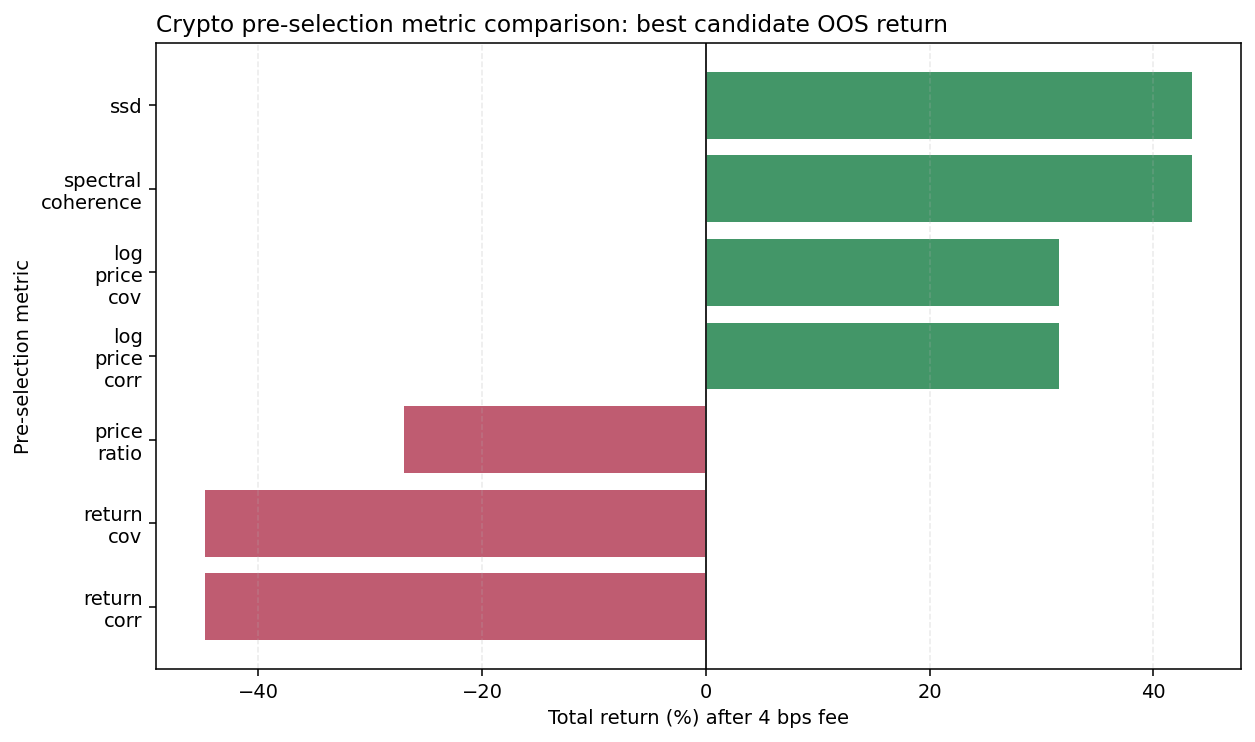

In [7]:
plot_df = summary.sort_values("total_return_pct")
colors = ["#2E8B57" if value >= 0 else "#B84A62" for value in plot_df["total_return_pct"]]

fig, ax = plt.subplots(figsize=(10, 5.8), dpi=140)
ax.barh(plot_df["metric"].str.replace("_", "\n"), plot_df["total_return_pct"], color=colors, alpha=0.9)
ax.axvline(0, color="#222222", linewidth=1)
ax.set_title("Crypto pre-selection metric comparison: best candidate OOS return", loc="left")
ax.set_xlabel("Total return (%) after 4 bps fee")
ax.set_ylabel("Pre-selection metric")
ax.grid(axis="x", linestyle="--", alpha=0.25)
plt.show()


## 8. Interpretation

Nếu một metric tạo return dương nhưng drawdown rất lớn. Có thể thấy pre-selection ảnh hưởng đến cặp được chọn và PnL diagnostic. Tuy nhiên cần bổ sung các bước tiếp theo như rolling re-selection, fee sensitivity, funding/slippage và portfolio-level aggregation